# Series de tiempo: temperatura mensual de Guatemala (1950-2026)

**Curso:** CC3084 - Data Science
**Archivo:** `guatemala_temperatura.csv`  
**Frecuencia:** mensual (`MS`, inicio de mes)  
**Variable objetivo:** `temperature_2m_c`
**Nombre:** Daniel Chet

Para el modelado se usa la temperatura del aire a 2 metros porque es la medida más interpretable como temperatura ambiental. Todas las capas se conservan en la exploración. La selección del modelo se hace solo con entrenamiento (AIC, BIC y residuos); el conjunto de prueba se usa después, evitando fuga de información.


## 0. Preparación y carga de datos


In [1]:
from pathlib import Path
import json
import warnings

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
from scipy import stats
from sklearn.metrics import mean_absolute_error, mean_squared_error
from statsmodels.graphics.tsaplots import plot_acf, plot_pacf
from statsmodels.stats.diagnostic import acorr_ljungbox
from statsmodels.tsa.holtwinters import ExponentialSmoothing, SimpleExpSmoothing
from statsmodels.tsa.seasonal import seasonal_decompose
from statsmodels.tsa.statespace.sarimax import SARIMAX
from statsmodels.tsa.stattools import adfuller, kpss

warnings.filterwarnings("ignore")
sns.set_theme(style="whitegrid", context="notebook")
plt.rcParams.update({"figure.figsize": (11, 5.5), "axes.titlesize": 13, "axes.labelsize": 11})

csv_candidates = [
    Path("guatemala_temperatura.csv"),
    Path.cwd() / "guatemala_temperatura.csv",
    Path(r"C:\UVG\Semestre8\CC3084 - Data Science\Tareas\SeriesdeTiempo\guatemala_temperatura.csv"),
]
CSV_PATH = next((p for p in csv_candidates if p.exists()), None)
if CSV_PATH is None:
    raise FileNotFoundError("No se encontró guatemala_temperatura.csv. Ejecute el notebook desde su carpeta.")

BASE_DIR = CSV_PATH.resolve().parent
OUTPUT_DIR = BASE_DIR / "output" / "series_tiempo"
FIG_DIR = OUTPUT_DIR / "figuras"
OUTPUT_DIR.mkdir(parents=True, exist_ok=True)
FIG_DIR.mkdir(parents=True, exist_ok=True)

df = pd.read_csv(CSV_PATH, parse_dates=["month"]).set_index("month").sort_index().asfreq("MS")
target = "temperature_2m_c"
y = df[target].copy()

temperature_cols = [
    "temperature_2m_c",
    "skin_temperature_c",
    "soil_temperature_layer_1_c",
    "soil_temperature_layer_2_c",
    "soil_temperature_layer_3_c",
    "soil_temperature_layer_4_c",
]
layer_labels = {
    "temperature_2m_c": "Aire a 2 m",
    "skin_temperature_c": "Superficie",
    "soil_temperature_layer_1_c": "Suelo capa 1",
    "soil_temperature_layer_2_c": "Suelo capa 2",
    "soil_temperature_layer_3_c": "Suelo capa 3",
    "soil_temperature_layer_4_c": "Suelo capa 4",
}

print(f"Dimensiones: {df.shape[0]} filas x {df.shape[1]} columnas")
print(f"Cobertura: {df.index.min().date()} a {df.index.max().date()}")
print(f"Frecuencia inferida: {pd.infer_freq(df.index)}")
print(f"Valores faltantes totales: {int(df.isna().sum().sum())}")
df.head()


Dimensiones: 918 filas x 9 columnas
Cobertura: 1950-01-01 a 2026-06-01
Frecuencia inferida: MS
Valores faltantes totales: 0


,year,month_num,dewpoint_2m_c,temperature_2m_c,skin_temperature_c,soil_temperature_layer_1_c,soil_temperature_layer_2_c,soil_temperature_layer_3_c,soil_temperature_layer_4_c
month,,,,,,,,,
1950-01-01,1950,1,16.685643,20.762313,21.077662,21.661654,21.679957,21.835225,22.458468
1950-02-01,1950,2,15.781276,21.051057,21.518684,22.132758,22.062957,21.964048,22.216061
1950-03-01,1950,3,17.330139,23.197594,23.838886,24.374884,24.100146,23.304599,22.380270
1950-04-01,1950,4,16.499826,23.661600,24.452373,25.059722,24.752231,24.059086,22.955561
1950-05-01,1950,5,19.011177,24.804521,25.501737,26.154377,25.941164,25.252762,23.687375


## Ejercicio 1. Exploración, extremos y tendencia

Cargue  el  archivo  con  R  o  con  Python  y  explórelo  un  poco,  ¿Cuáles  son  los  extremos  de  la 
temperatura  promedio  de  la  tierra?  ¿y  por  capa?  ¿Como  ha  sido  la  tendencia,  ha  bajado,  subido,  se  ha 
mantenido constante alrededor de un valor?  Para cada serie se calcula mínimo, máximo, fecha y pendiente lineal en °C por década.


              mínimo_C fecha_mínimo  máximo_C fecha_máximo  pendiente_C_década  p_tendencia
capa                                                                                       
Aire a 2 m      18.970   1956-01-01    28.686   2024-05-01               0.171          0.0
Superficie      19.146   1956-01-01    29.736   2024-05-01               0.168          0.0
Suelo capa 1    19.838   1956-01-01    30.293   2024-05-01               0.168          0.0
Suelo capa 2    19.960   1956-01-01    29.804   2024-05-01               0.167          0.0
Suelo capa 3    20.487   1956-01-01    28.347   2024-05-01               0.166          0.0
Suelo capa 4    21.567   1976-02-01    26.877   2024-06-01               0.165          0.0

Extremo global entre las seis series de temperatura: 18.970 a 30.293 °C
Punto de rocío (referencia): 14.199 a 21.960 °C


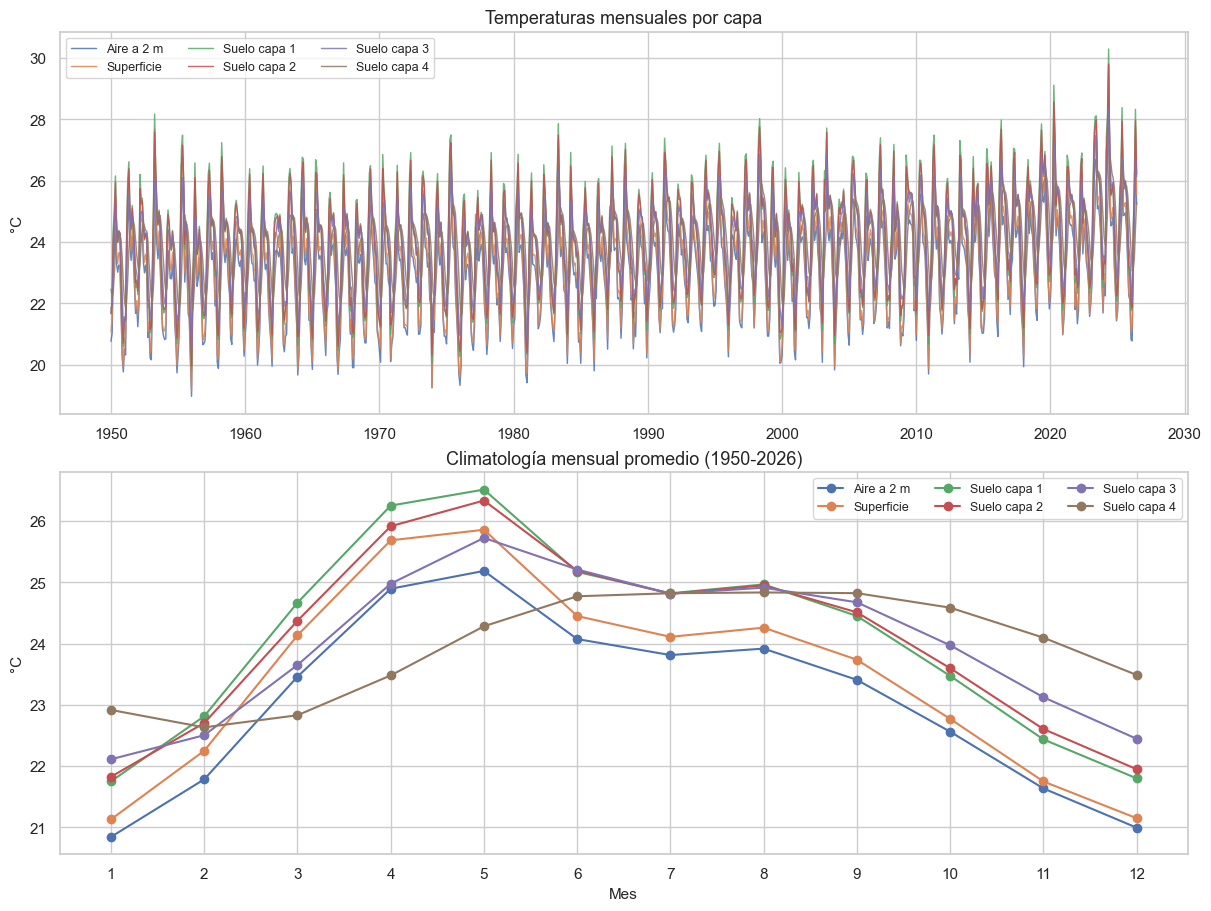

In [2]:
rows = []
for col in temperature_cols:
    minimum_date = df[col].idxmin()
    maximum_date = df[col].idxmax()
    regression = stats.linregress(np.arange(len(df)) / 120.0, df[col])
    rows.append({
        "capa": layer_labels[col],
        "mínimo_C": df.loc[minimum_date, col],
        "fecha_mínimo": minimum_date.date().isoformat(),
        "máximo_C": df.loc[maximum_date, col],
        "fecha_máximo": maximum_date.date().isoformat(),
        "pendiente_C_década": regression.slope,
        "p_tendencia": regression.pvalue,
    })

extremos = pd.DataFrame(rows).set_index("capa")
extremos.to_csv(OUTPUT_DIR / "01_extremos_y_tendencias.csv", encoding="utf-8-sig")
print(extremos.round({"mínimo_C": 3, "máximo_C": 3, "pendiente_C_década": 3, "p_tendencia": 4}).to_string())

global_min = df[temperature_cols].min().min()
global_max = df[temperature_cols].max().max()
dew_min, dew_max = df["dewpoint_2m_c"].min(), df["dewpoint_2m_c"].max()
print(f"\nExtremo global entre las seis series de temperatura: {global_min:.3f} a {global_max:.3f} °C")
print(f"Punto de rocío (referencia): {dew_min:.3f} a {dew_max:.3f} °C")

fig, axes = plt.subplots(2, 1, figsize=(12, 9), constrained_layout=True)
for col in temperature_cols:
    axes[0].plot(df.index, df[col], lw=1.05, alpha=0.85, label=layer_labels[col])
axes[0].set(title="Temperaturas mensuales por capa", ylabel="°C")
axes[0].legend(ncol=3, fontsize=9)

monthly_climatology = df.groupby("month_num")[temperature_cols].mean()
for col in temperature_cols:
    axes[1].plot(monthly_climatology.index, monthly_climatology[col], marker="o", label=layer_labels[col])
axes[1].set(title="Climatología mensual promedio (1950-2026)", xlabel="Mes", ylabel="°C", xticks=range(1, 13))
axes[1].legend(ncol=3, fontsize=9)
fig.savefig(FIG_DIR / "01_exploracion_capas.png", dpi=180, bbox_inches="tight")
plt.show()


Entre las seis series de temperatura, el mínimo es 18.970 °C y el máximo es 30.293 °C. Para el aire a 2 m, el mínimo fue 18.970 °C (enero de 1956) y el máximo 28.686 °C (mayo de 2024). Todas las pendientes son positivas: el calentamiento estimado es cercano a 0.17 °C por década en el aire, superficie y capas del suelo. La capa 4 amortigua más la oscilación estacional, pero también presenta tendencia ascendente.


## Ejercicio 2. División entrenamiento-prueba
Divida el conjunto en entrenamiento y prueba. Deje los últimos 36 meses para probar. 

Entrenamiento: 1950-01-01 a 2023-06-01 (882 meses)
Prueba:        2023-07-01 a 2026-06-01 (36 meses)


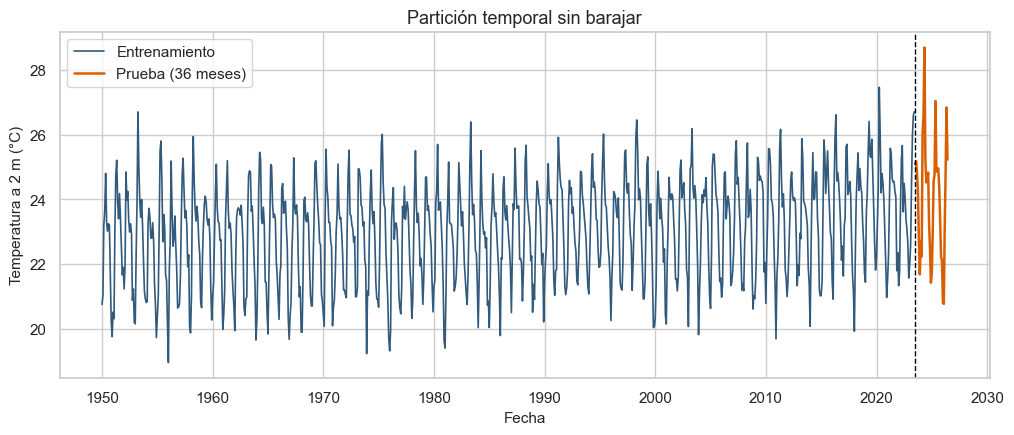

In [3]:
n_test = 36
train = y.iloc[:-n_test]
test = y.iloc[-n_test:]

assert len(test) == 36
assert train.index.max() < test.index.min()
print(f"Entrenamiento: {train.index.min().date()} a {train.index.max().date()} ({len(train)} meses)")
print(f"Prueba:        {test.index.min().date()} a {test.index.max().date()} ({len(test)} meses)")

fig, ax = plt.subplots(figsize=(12, 4.5))
ax.plot(train, label="Entrenamiento", color="#315a7d", lw=1.2)
ax.plot(test, label="Prueba (36 meses)", color="#d95f02", lw=1.8)
ax.axvline(test.index.min(), color="black", ls="--", lw=1)
ax.set(title="Partición temporal sin barajar", ylabel="Temperatura a 2 m (°C)", xlabel="Fecha")
ax.legend()
fig.savefig(FIG_DIR / "02_particion_temporal.png", dpi=180, bbox_inches="tight")
plt.show()


## Ejercicio 3. Descomposición, tendencia y estacionariedad

Conviértalo en una serie de tiempo y analícela (explique sus razonamientos). Para esto:

- Explore la serie, descompóngala en componentes y analícelos.
- Determine si tiene tendencia.
- Determine si es estacionaria; recuerde que debe ser estacionaria en media y en varianza.


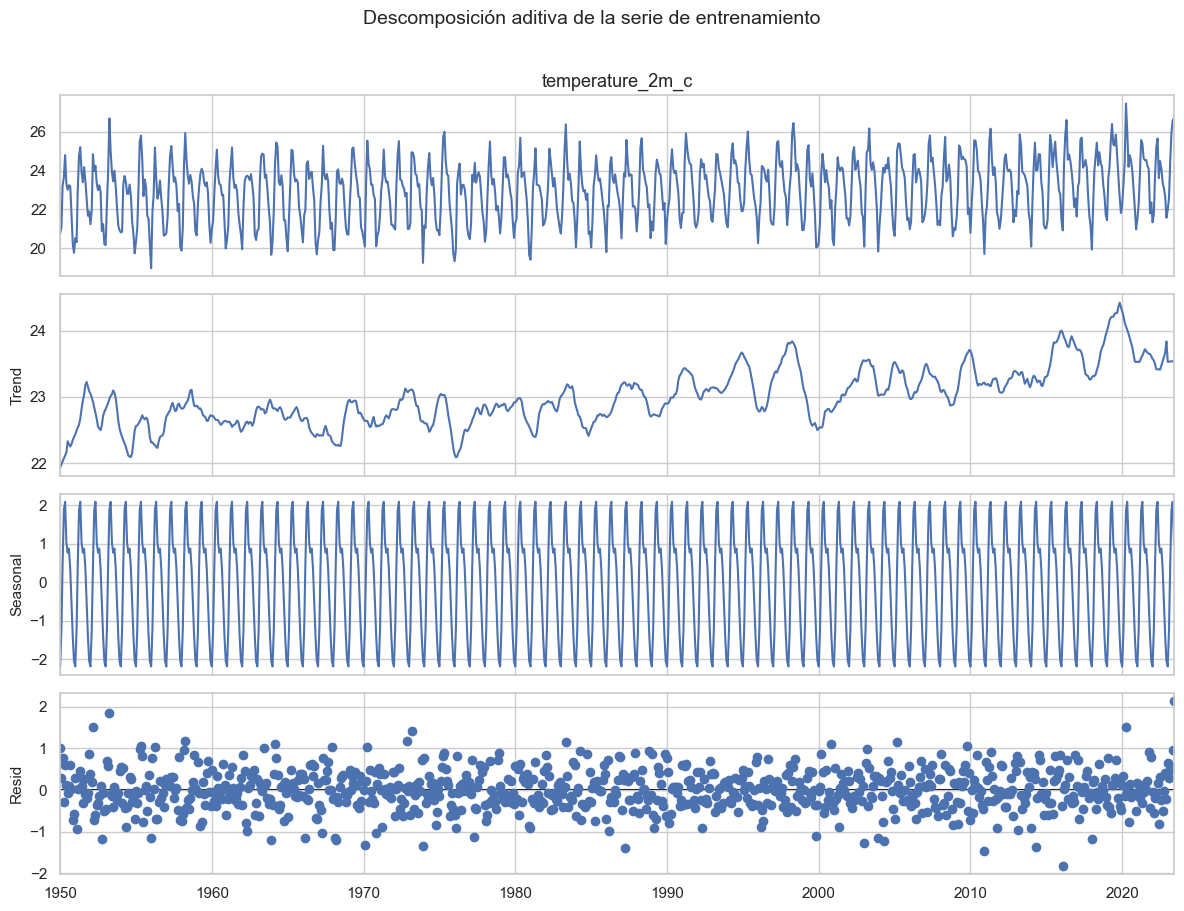

Pendiente lineal en entrenamiento: 0.158 °C/década (p=7.22e-11)
Fuerza de tendencia: 0.472
Fuerza de estacionalidad: 0.893


In [4]:
decomp = seasonal_decompose(train, model="additive", period=12, extrapolate_trend="freq")

fig = decomp.plot()
fig.set_size_inches(12, 9)
fig.suptitle("Descomposición aditiva de la serie de entrenamiento", y=1.01, fontsize=14)
fig.tight_layout()
fig.savefig(FIG_DIR / "03_descomposicion.png", dpi=180, bbox_inches="tight")
plt.show()

trend_strength = max(0.0, 1 - np.nanvar(decomp.resid) / np.nanvar(decomp.trend + decomp.resid))
seasonal_strength = max(0.0, 1 - np.nanvar(decomp.resid) / np.nanvar(decomp.seasonal + decomp.resid))
trend_fit = stats.linregress(np.arange(len(train)) / 120.0, train)
print(f"Pendiente lineal en entrenamiento: {trend_fit.slope:.3f} °C/década (p={trend_fit.pvalue:.3g})")
print(f"Fuerza de tendencia: {trend_strength:.3f}")
print(f"Fuerza de estacionalidad: {seasonal_strength:.3f}")


          ADF_estadístico   ADF_p  KPSS_estadístico  KPSS_p    n
serie                                                           
Original           -4.357  0.0004            2.4193    0.01  882
Levene entre mitades: estadístico=0.008, p=0.931
Desv. estándar por mitad: 1.523 vs 1.507 °C


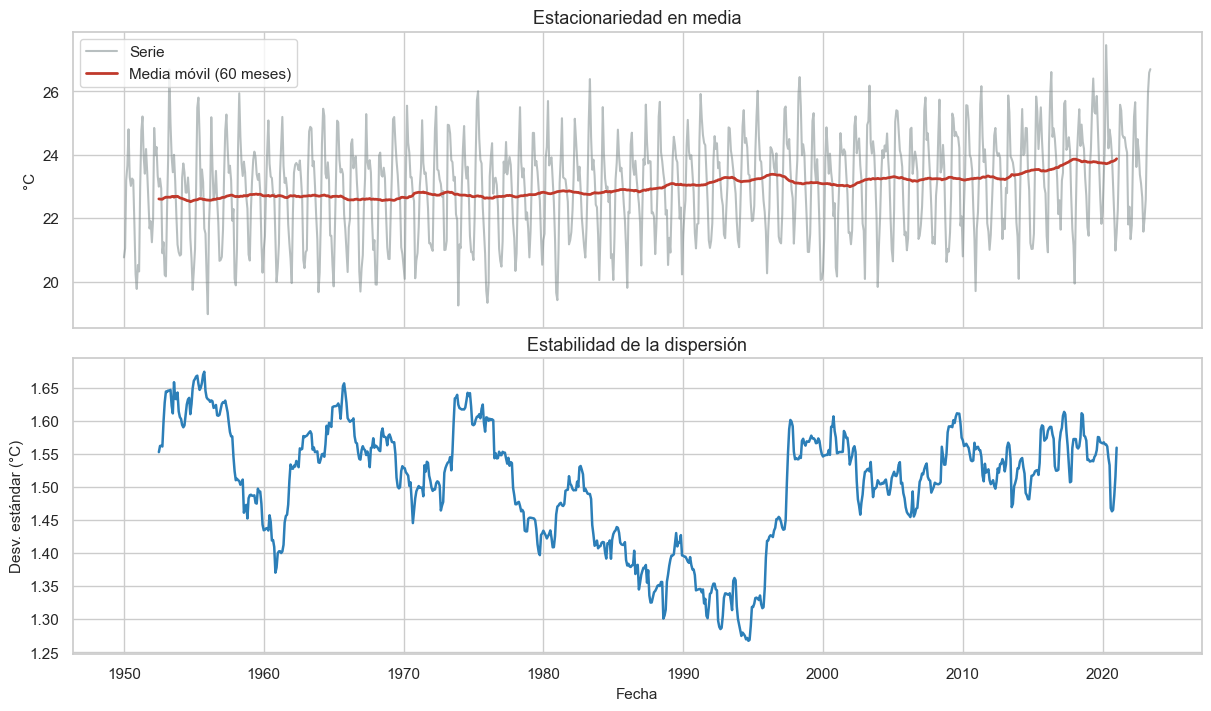

In [5]:
def stationarity_tests(series, label):
    clean = pd.Series(series).dropna()
    adf_result = adfuller(clean, autolag="AIC")
    kpss_result = kpss(clean, regression="c", nlags="auto")
    return {
        "serie": label,
        "ADF_estadístico": adf_result[0],
        "ADF_p": adf_result[1],
        "KPSS_estadístico": kpss_result[0],
        "KPSS_p": kpss_result[1],
        "n": len(clean),
    }

half = len(train) // 2
levene_raw = stats.levene(train.iloc[:half], train.iloc[half:], center="median")
std_first, std_second = train.iloc[:half].std(), train.iloc[half:].std()
raw_tests = pd.DataFrame([stationarity_tests(train, "Original")]).set_index("serie")
print(raw_tests.round(4).to_string())
print(f"Levene entre mitades: estadístico={levene_raw.statistic:.3f}, p={levene_raw.pvalue:.3f}")
print(f"Desv. estándar por mitad: {std_first:.3f} vs {std_second:.3f} °C")

rolling_mean = train.rolling(60, center=True).mean()
rolling_std = train.rolling(60, center=True).std()
fig, axes = plt.subplots(2, 1, figsize=(12, 7), sharex=True, constrained_layout=True)
axes[0].plot(train, color="#7f8c8d", alpha=0.55, label="Serie")
axes[0].plot(rolling_mean, color="#c0392b", lw=2, label="Media móvil (60 meses)")
axes[0].set(title="Estacionariedad en media", ylabel="°C")
axes[0].legend()
axes[1].plot(rolling_std, color="#2c7fb8", lw=1.8)
axes[1].set(title="Estabilidad de la dispersión", ylabel="Desv. estándar (°C)", xlabel="Fecha")
fig.savefig(FIG_DIR / "04_estacionariedad_original.png", dpi=180, bbox_inches="tight")
plt.show()


La descomposición muestra un patrón anual fuerte y una tendencia creciente. ADF rechaza raíz unitaria, pero KPSS rechaza estacionariedad; no son hipótesis equivalentes y pueden discrepar ante tendencia determinista y estacionalidad. La media móvil y la tendencia respaldan tratar la media como no estacionaria. En varianza, Levene no rechaza igualdad entre mitades (p ≈ 0.93) y las desviaciones son casi iguales (1.523 vs 1.507 °C).


## Ejercicio 4. Transformación y tres modelos ARIMA/SARIMA
Haga modelos de predicción usando alguno de los modelos ARIMA (AR, MA, ARIMA o SARIMA)  
- Transforme  la  serie  para  lograr  que  sea  estacionaria  en  media  y  en  varianza  en  caso  de  que  no  lo 
fuera. 
- Verifique que las transformaciones lograron hacerla estacionaria en media, si no es así aplique otra 
diferenciación y verifique nuevamente. 
- Estime  los  parámetros  del  modelo.  Utilice  las  funciones  de  autocorrelación  y  de  autocorrelación 
parcial para esto. 
- Entrene el modelo con los parámetros estimados y el conjunto de entrenamiento. 
- Haga  2  modelos  más,  puede usar  el  autoarima  de  R  si trabaja  en  R.  Entrénelos  con  el conjunto  de 
entrenamiento. 

                                 ADF_estadístico   ADF_p  KPSS_estadístico  KPSS_p    n
serie                                                                                  
Original                                 -4.3570  0.0004            2.4193    0.01  882
Diferencia estacional (12)               -7.9423  0.0000            0.0126    0.10  870
Diferencia estacional + regular         -13.7876  0.0000            0.0956    0.10  869
Levene después de D=1 estacional: p=0.638
La diferencia estacional basta: ADF rechaza no estacionariedad y KPSS no rechaza estacionariedad.


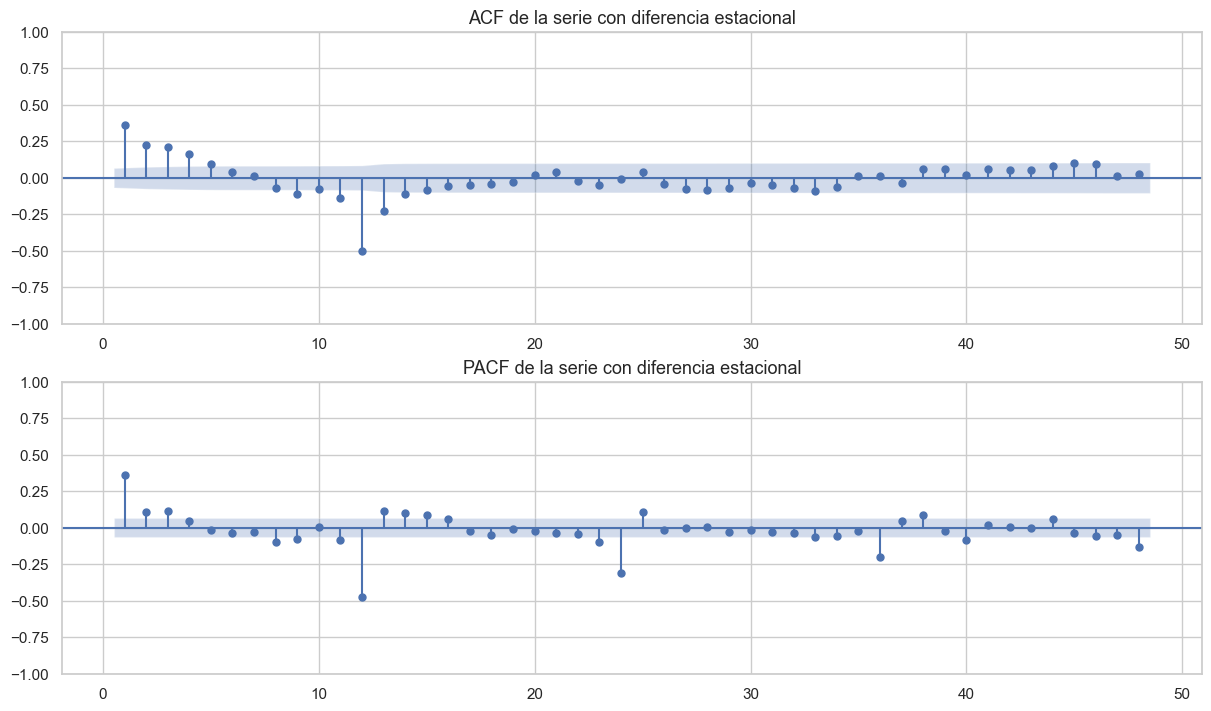

In [6]:
diff12 = train.diff(12).dropna()
diff1_diff12 = train.diff(12).diff().dropna()
stationarity_table = pd.DataFrame([
    stationarity_tests(train, "Original"),
    stationarity_tests(diff12, "Diferencia estacional (12)"),
    stationarity_tests(diff1_diff12, "Diferencia estacional + regular"),
]).set_index("serie")
stationarity_table.to_csv(OUTPUT_DIR / "02_pruebas_estacionariedad.csv", encoding="utf-8-sig")
print(stationarity_table.round(4).to_string())

half_d = len(diff12) // 2
levene_diff = stats.levene(diff12.iloc[:half_d], diff12.iloc[half_d:], center="median")
print(f"Levene después de D=1 estacional: p={levene_diff.pvalue:.3f}")
print("La diferencia estacional basta: ADF rechaza no estacionariedad y KPSS no rechaza estacionariedad.")

fig, axes = plt.subplots(2, 1, figsize=(12, 7), constrained_layout=True)
plot_acf(diff12, lags=48, ax=axes[0], zero=False)
plot_pacf(diff12, lags=48, ax=axes[1], zero=False, method="ywm")
axes[0].set_title("ACF de la serie con diferencia estacional")
axes[1].set_title("PACF de la serie con diferencia estacional")
fig.savefig(FIG_DIR / "05_acf_pacf.png", dpi=180, bbox_inches="tight")
plt.show()


La ACF/PACF presenta dependencia importante en rezago 1 y un pico estacional negativo en 12. Esto motiva un modelo manual parsimonioso SARIMA(1,0,1)(0,1,1)[12]. Se ajustan dos alternativas para contrastar complejidad y una diferenciación regular adicional.


In [7]:
model_specs = {
    "SARIMA manual (1,0,1)(0,1,1)[12]": ((1, 0, 1), (0, 1, 1, 12)),
    "SARIMA alt. 1 (2,0,1)(0,1,1)[12]": ((2, 0, 1), (0, 1, 1, 12)),
    "SARIMA alt. 2 (0,1,1)(0,1,1)[12]": ((0, 1, 1), (0, 1, 1, 12)),
}

fits = {}
comparison_rows = []
for name, (order, seasonal_order) in model_specs.items():
    fit = SARIMAX(
        train,
        order=order,
        seasonal_order=seasonal_order,
        trend="n",
        enforce_stationarity=False,
        enforce_invertibility=False,
    ).fit(disp=False, maxiter=300)
    fits[name] = fit
    residuals = pd.Series(fit.resid).dropna().iloc[24:]
    lb = acorr_ljungbox(residuals, lags=[12, 24, 36], return_df=True)
    comparison_rows.append({
        "modelo": name,
        "AIC": fit.aic,
        "BIC": fit.bic,
        "Ljung_Box_p12": lb.loc[12, "lb_pvalue"],
        "Ljung_Box_p24": lb.loc[24, "lb_pvalue"],
        "Ljung_Box_p36": lb.loc[36, "lb_pvalue"],
        "convergió": bool(fit.mle_retvals.get("converged", False)),
    })

model_comparison = pd.DataFrame(comparison_rows).set_index("modelo").sort_values("AIC")
model_comparison.to_csv(OUTPUT_DIR / "03_comparacion_sarima.csv", encoding="utf-8-sig")
print(model_comparison.round(3).to_string())


                                       AIC       BIC  Ljung_Box_p12  Ljung_Box_p24  Ljung_Box_p36  convergió
modelo                                                                                                      
SARIMA manual (1,0,1)(0,1,1)[12]  1421.005  1440.015          0.609          0.688          0.604       True
SARIMA alt. 1 (2,0,1)(0,1,1)[12]  1422.396  1446.158          0.701          0.763          0.701       True
SARIMA alt. 2 (0,1,1)(0,1,1)[12]  1460.421  1474.674          0.027          0.051          0.036       True


## Ejercicio 5. Validación del mejor SARIMA

Valide uno los modelos y analice:

- Contrastes sobre los coeficientes:
  - Significación.
  - Raíces comunes.
- Diagnóstico:
  - Este análisis se basa habitualmente en los residuos, que no deben estar correlacionados con el pasado.
  - Su correlograma no debe tener ninguna correlación significativamente distinta de cero.
- Contrastes respecto a modelos alternativos:
  - Métricas AIC y BIC.


Modelo seleccionado: SARIMA manual (1,0,1)(0,1,1)[12]

Coeficientes:
           coeficiente  error_estándar         z    p  significativo_5pct
ar.L1         0.82478         0.03877  21.27270  0.0                True
ma.L1        -0.54897         0.05679  -9.66711  0.0                True
ma.S.L12     -0.91757         0.01747 -52.53450  0.0                True
sigma2        0.29982         0.01332  22.51080  0.0                True

Módulo mínimo raíz AR: 1.212
Módulo mínimo raíz MA: 1.007
Distancia mínima AR-MA: 0.205
Raíces comunes aproximadas (<0.05): False

Ljung-Box:
     lb_stat  lb_pvalue
12  10.0847     0.6085
24  20.1473     0.6884
36  33.1669     0.6041


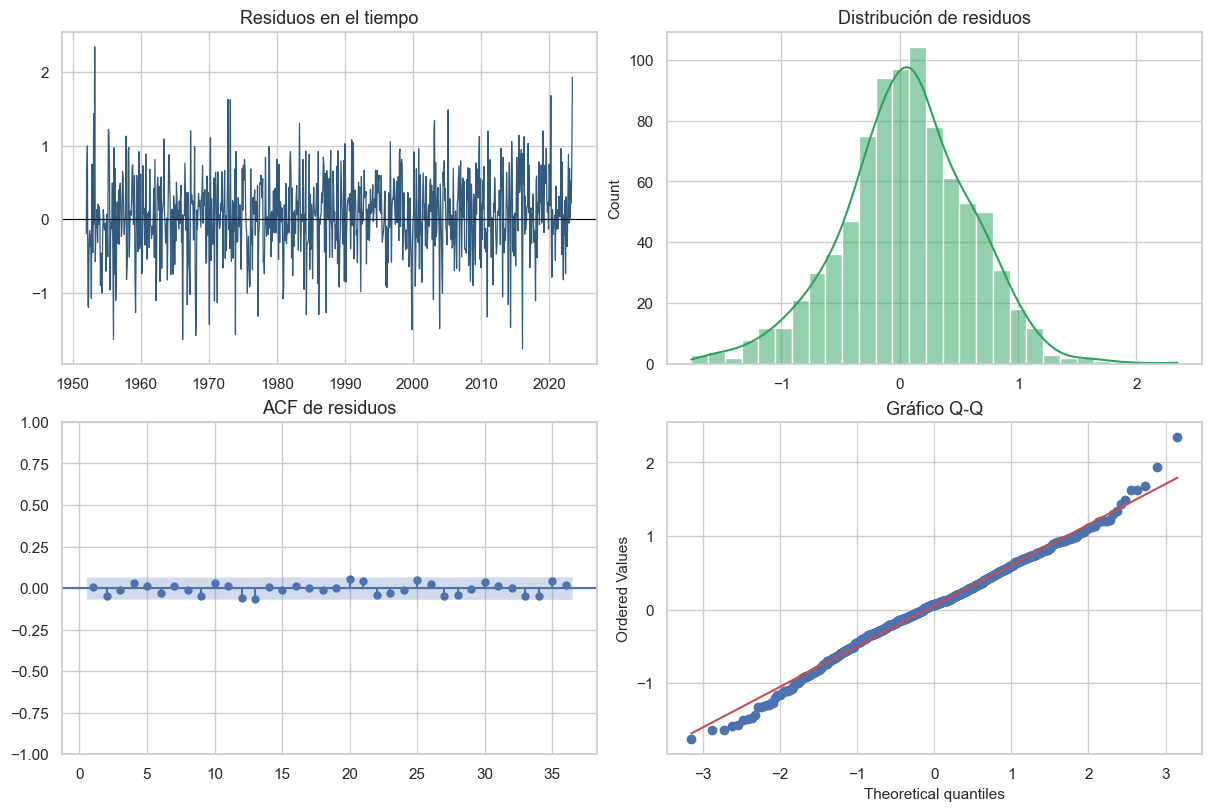

In [8]:
# Elegibilidad definida únicamente con entrenamiento: convergencia y residuos blancos a 5%.
eligible = model_comparison[
    model_comparison["convergió"]
    & (model_comparison["Ljung_Box_p12"] > 0.05)
    & (model_comparison["Ljung_Box_p24"] > 0.05)
    & (model_comparison["Ljung_Box_p36"] > 0.05)
]
best_name = eligible["AIC"].idxmin() if len(eligible) else model_comparison["AIC"].idxmin()
best_fit = fits[best_name]
print("Modelo seleccionado:", best_name)

coef_table = pd.DataFrame({
    "coeficiente": best_fit.params,
    "error_estándar": best_fit.bse,
    "z": best_fit.params / best_fit.bse,
    "p": best_fit.pvalues,
})
coef_table["significativo_5pct"] = coef_table["p"] < 0.05
coef_table.to_csv(OUTPUT_DIR / "04_coeficientes_mejor_sarima.csv", encoding="utf-8-sig")
print("\nCoeficientes:\n", coef_table.round(5).to_string())

ar_roots = np.asarray(best_fit.arroots)
ma_roots = np.asarray(best_fit.maroots)
min_ar_modulus = float(np.min(np.abs(ar_roots))) if ar_roots.size else np.inf
min_ma_modulus = float(np.min(np.abs(ma_roots))) if ma_roots.size else np.inf
common_root_distance = float(np.min(np.abs(ar_roots[:, None] - ma_roots[None, :]))) if ar_roots.size and ma_roots.size else np.inf
print(f"\nMódulo mínimo raíz AR: {min_ar_modulus:.3f}")
print(f"Módulo mínimo raíz MA: {min_ma_modulus:.3f}")
print(f"Distancia mínima AR-MA: {common_root_distance:.3f}")
print("Raíces comunes aproximadas (<0.05):", common_root_distance < 0.05)

best_resid = pd.Series(best_fit.resid).dropna().iloc[24:]
lb_best = acorr_ljungbox(best_resid, lags=[12, 24, 36], return_df=True)
print("\nLjung-Box:\n", lb_best.round(4).to_string())

fig, axes = plt.subplots(2, 2, figsize=(12, 8), constrained_layout=True)
axes[0, 0].plot(best_resid, color="#315a7d", lw=0.9)
axes[0, 0].axhline(0, color="black", lw=0.8)
axes[0, 0].set_title("Residuos en el tiempo")
sns.histplot(best_resid, kde=True, ax=axes[0, 1], color="#2ca25f")
axes[0, 1].set_title("Distribución de residuos")
plot_acf(best_resid, lags=36, zero=False, ax=axes[1, 0])
axes[1, 0].set_title("ACF de residuos")
stats.probplot(best_resid, dist="norm", plot=axes[1, 1])
axes[1, 1].set_title("Gráfico Q-Q")
fig.savefig(FIG_DIR / "06_diagnostico_residuos.png", dpi=180, bbox_inches="tight")
plt.show()


El SARIMA manual es el seleccionado, ya que tiene el menor AIC y BIC entre los modelos con residuos blancos. Sus coeficientes AR(1), MA(1) y MA estacional son significativos. Las raíces AR y MA están fuera del círculo unitario (módulos mínimos ≈ 1.212 y 1.007) y la distancia mínima entre ambas familias es ≈ 0.205, por lo que no hay raíces comunes aproximadas. Ljung-Box no rechaza ausencia de autocorrelación en 12, 24 ni 36 rezagos (p > 0.60).


## Ejercicio 6. Predicción sobre los 36 meses de prueba
Haga una predicción usando el conjunto de prueba, y el mejor modelo determinado en el ejercicio 
anterior

MAE                        0.6635
RMSE                       0.8934
MAPE_pct                   2.6935
MASE                       1.0374
Sesgo_actual_menos_pred    0.3955
Cobertura del intervalo de 95%: 86.1%


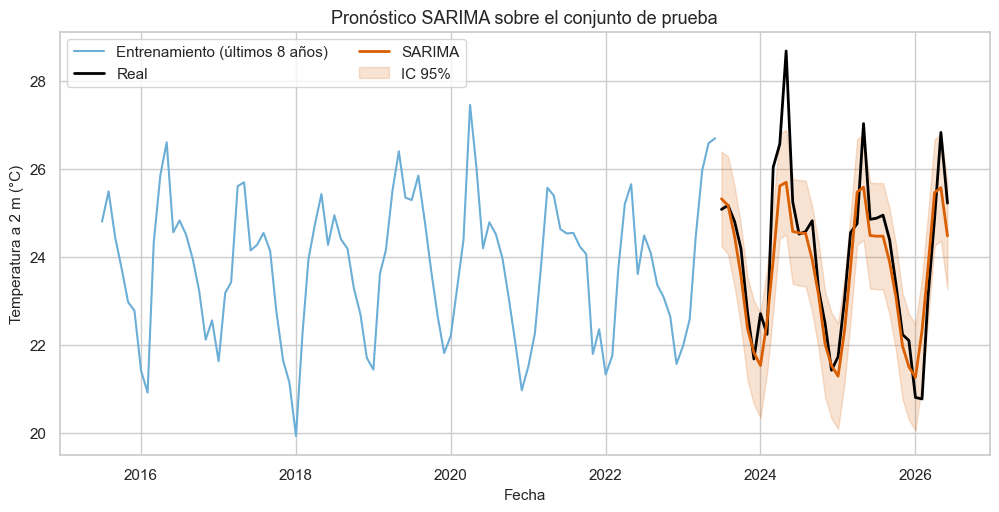

In [9]:
def forecast_metrics(actual, forecast, seasonal_scale):
    actual = np.asarray(actual, dtype=float)
    forecast = np.asarray(forecast, dtype=float)
    error = actual - forecast
    return {
        "MAE": float(mean_absolute_error(actual, forecast)),
        "RMSE": float(np.sqrt(mean_squared_error(actual, forecast))),
        "MAPE_pct": float(np.mean(np.abs(error / actual)) * 100),
        "MASE": float(np.mean(np.abs(error)) / seasonal_scale),
        "Sesgo_actual_menos_pred": float(np.mean(error)),
    }

seasonal_scale = float(np.mean(np.abs(train.iloc[12:].to_numpy() - train.iloc[:-12].to_numpy())))
best_forecast_obj = best_fit.get_forecast(steps=len(test))
sarima_pred = best_forecast_obj.predicted_mean
sarima_ci = best_forecast_obj.conf_int(alpha=0.05)
sarima_ci.columns = ["límite_inferior_95", "límite_superior_95"]
sarima_metrics = forecast_metrics(test, sarima_pred, seasonal_scale)
coverage = float(((test >= sarima_ci.iloc[:, 0]) & (test <= sarima_ci.iloc[:, 1])).mean())
print(pd.Series(sarima_metrics).round(4).to_string())
print(f"Cobertura del intervalo de 95%: {coverage:.1%}")

test_forecast_table = pd.concat(
    [test.rename("real"), sarima_pred.rename("pronóstico"), sarima_ci], axis=1
)
test_forecast_table.to_csv(OUTPUT_DIR / "05_pronostico_prueba_sarima.csv", encoding="utf-8-sig")

fig, ax = plt.subplots(figsize=(12, 5.5))
ax.plot(train.iloc[-96:], label="Entrenamiento (últimos 8 años)", color="#6baed6")
ax.plot(test, label="Real", color="black", lw=2)
ax.plot(sarima_pred, label="SARIMA", color="#d95f02", lw=2)
ax.fill_between(test.index, sarima_ci.iloc[:, 0], sarima_ci.iloc[:, 1], color="#d95f02", alpha=0.18, label="IC 95%")
ax.set(title="Pronóstico SARIMA sobre el conjunto de prueba", ylabel="Temperatura a 2 m (°C)", xlabel="Fecha")
ax.legend(ncol=2)
fig.savefig(FIG_DIR / "07_pronostico_prueba.png", dpi=180, bbox_inches="tight")
plt.show()


En los 36 meses reservados, el SARIMA obtiene MAE 0.664 °C, RMSE 0.893 °C y MAPE 2.69%. El sesgo real - pronóstico es +0.395 °C, señal de subestimación promedio. La cobertura del intervalo nominal de 95% es 86.1%, menor que la deseada, en buena parte por el episodio excepcionalmente cálido de 2024.


## Ejercicio 7. Holt-Winters, suavizamiento exponencial y naive estacional
Utilice  otros  modelos  para  predecir  (holt  winters,  suavizamiento  exponencial  y  seasonal  naive). 
Compare resultados

                                     MAE    RMSE  MAPE_pct    MASE  Sesgo_actual_menos_pred
SARIMA                            0.6635  0.8934    2.6935  1.0374                   0.3955
Holt-Winters aditivo              0.6978  0.9125    2.9598  1.0910                  -0.4251
Naive estacional                  0.7973  0.9872    3.2782  1.2466                   0.0902
Suavizamiento exponencial simple  2.7844  3.2050   12.1158  4.3532                  -2.6483


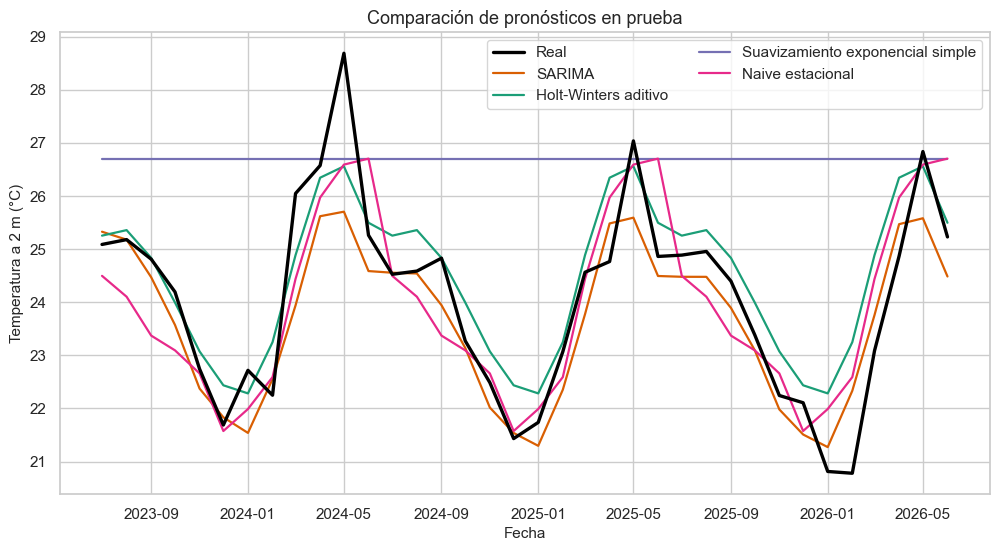

In [10]:
holt_winters_fit = ExponentialSmoothing(
    train,
    trend="add",
    damped_trend=True,
    seasonal="add",
    seasonal_periods=12,
    initialization_method="estimated",
).fit(optimized=True)
holt_winters_pred = holt_winters_fit.forecast(len(test))

ses_fit = SimpleExpSmoothing(train, initialization_method="estimated").fit(optimized=True)
ses_pred = ses_fit.forecast(len(test))

seasonal_naive_pred = pd.Series(
    np.resize(train.iloc[-12:].to_numpy(), len(test)), index=test.index, name="Naive estacional"
)

all_forecasts = {
    "SARIMA": sarima_pred,
    "Holt-Winters aditivo": holt_winters_pred,
    "Suavizamiento exponencial simple": ses_pred,
    "Naive estacional": seasonal_naive_pred,
}
metrics_table = pd.DataFrame({
    name: forecast_metrics(test, pred, seasonal_scale) for name, pred in all_forecasts.items()
}).T.sort_values("RMSE")
metrics_table.to_csv(OUTPUT_DIR / "06_comparacion_metodos_prueba.csv", encoding="utf-8-sig")
print(metrics_table.round(4).to_string())

fig, ax = plt.subplots(figsize=(12, 6))
ax.plot(test, label="Real", color="black", lw=2.4, zorder=5)
colors = ["#d95f02", "#1b9e77", "#7570b3", "#e7298a"]
for (name, pred), color in zip(all_forecasts.items(), colors):
    ax.plot(pred, label=name, lw=1.6, color=color)
ax.set(title="Comparación de pronósticos en prueba", ylabel="Temperatura a 2 m (°C)", xlabel="Fecha")
ax.legend(ncol=2)
fig.savefig(FIG_DIR / "08_comparacion_metodos.png", dpi=180, bbox_inches="tight")
plt.show()


SARIMA queda primero por RMSE (0.893 °C), seguido de Holt-Winters (0.912 °C) y naive estacional (0.987 °C). El suavizamiento exponencial simple falla porque no representa la estacionalidad anual (RMSE ≈ 3.205 °C, MAPE ≈ 12.12%). El naive estacional es una referencia fuerte; superarlo confirma que el SARIMA añade señal útil, aunque la mejora es moderada.


## Ejercicio 8. ¿Puede predecir valores actuales?
Determine si su modelo es capaz de predecir valores actuales.

Desempeño en los 12 meses más recientes del archivo:
MAE                        0.6522
RMSE                       0.7487
MAPE_pct                   2.7821
MASE                       1.0197
Sesgo_actual_menos_pred    0.1047
Mejora de RMSE frente al naive estacional (36 meses): 9.5%



Pronóstico después del último dato disponible (no validable todavía):
            pronóstico  límite_inferior_95  límite_superior_95
2026-07-01      24.672              23.574              25.769
2026-08-01      24.671              23.535              25.808
2026-09-01      24.159              22.996              25.322
2026-10-01      23.288              22.107              24.469
2026-11-01      22.159              20.966              23.353
2026-12-01      21.623              20.421              22.825
2027-01-01      21.422              20.215              22.630
2027-02-01      22.288              21.076              23.499
2027-03-01      23.970              22.756              25.184
2027-04-01      25.481              24.265              26.697
2027-05-01      26.079              24.861              27.297
2027-06-01      24.671              23.452              25.889


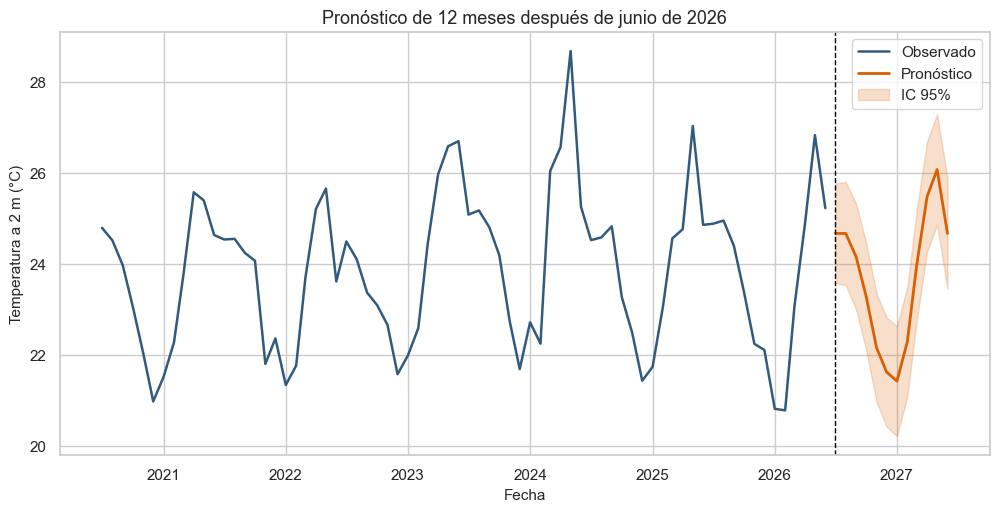

In [11]:
last12_metrics = forecast_metrics(test.iloc[-12:], sarima_pred.iloc[-12:], seasonal_scale)
rmse_improvement_vs_naive = 1 - metrics_table.loc["SARIMA", "RMSE"] / metrics_table.loc["Naive estacional", "RMSE"]
print("Desempeño en los 12 meses más recientes del archivo:")
print(pd.Series(last12_metrics).round(4).to_string())
print(f"Mejora de RMSE frente al naive estacional (36 meses): {rmse_improvement_vs_naive:.1%}")

best_order, best_seasonal_order = model_specs[best_name]
full_fit = SARIMAX(
    y,
    order=best_order,
    seasonal_order=best_seasonal_order,
    trend="n",
    enforce_stationarity=False,
    enforce_invertibility=False,
).fit(disp=False, maxiter=300)
future_obj = full_fit.get_forecast(steps=12)
future_pred = future_obj.predicted_mean
future_ci = future_obj.conf_int(alpha=0.05)
future_ci.columns = ["límite_inferior_95", "límite_superior_95"]
future_table = pd.concat([future_pred.rename("pronóstico"), future_ci], axis=1)
future_table.to_csv(OUTPUT_DIR / "07_pronostico_jul2026_jun2027.csv", encoding="utf-8-sig")
print("\nPronóstico después del último dato disponible (no validable todavía):")
print(future_table.round(3).to_string())

fig, ax = plt.subplots(figsize=(12, 5.5))
ax.plot(y.iloc[-72:], label="Observado", color="#315a7d", lw=1.8)
ax.plot(future_pred, label="Pronóstico", color="#d95f02", lw=2)
ax.fill_between(future_pred.index, future_ci.iloc[:, 0], future_ci.iloc[:, 1], color="#d95f02", alpha=0.2, label="IC 95%")
ax.axvline(future_pred.index.min(), color="black", ls="--", lw=1)
ax.set(title="Pronóstico de 12 meses después de junio de 2026", ylabel="Temperatura a 2 m (°C)", xlabel="Fecha")
ax.legend()
fig.savefig(FIG_DIR / "09_pronostico_futuro.png", dpi=180, bbox_inches="tight")
plt.show()

summary = {
    "serie_objetivo": target,
    "entrenamiento_fin": train.index.max().date().isoformat(),
    "prueba_inicio": test.index.min().date().isoformat(),
    "prueba_fin": test.index.max().date().isoformat(),
    "modelo_seleccionado": best_name,
    "pendiente_C_decada": float(trend_fit.slope),
    "AIC": float(best_fit.aic),
    "BIC": float(best_fit.bic),
    "RMSE_prueba": sarima_metrics["RMSE"],
    "MAPE_prueba_pct": sarima_metrics["MAPE_pct"],
    "cobertura_IC95": coverage,
    "RMSE_ultimos_12": last12_metrics["RMSE"],
    "MAPE_ultimos_12_pct": last12_metrics["MAPE_pct"],
}
with open(OUTPUT_DIR / "resumen_clave.json", "w", encoding="utf-8") as f:
    json.dump(summary, f, ensure_ascii=False, indent=2)


### Conclusión

**El modelo si es útil para predecir valores recientes**

Sin embargo es limitado, ya que en los últimos 12 meses observados logra RMSE ≈ 0.749 °C y MAPE ≈ 2.78%; en toda la prueba supera al naive estacional en RMSE por aproximadamente 9.5%. Sin embargo, no anticipa bien extremos extraordinarios: subestimó el máximo de mayo de 2024 y su intervalo de 95% cubrió solo 86.1% de los datos. Por tanto, es razonable para pronóstico mensual central, pero conviene recalibrar intervalos, actualizarlo conforme llegan datos y no usarlo solo para alertas de extremos.

El pronóstico julio de 2026-junio de 2027 se genera al reentrenar el SARIMA con los 918 meses disponibles. Es una proyección futura, no evidencia adicional de validación.
